In [9]:
# Input Image
# SET PYTHONPATH to the parent directory 
import os
import sys
import torch
import matplotlib.pyplot as plt
plt.rc('text', usetex=False)
from einops import rearrange
if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))


import torch 
import numpy as np
from typing import List
from scipy.linalg import dft
from einops import rearrange, repeat
from hippy2d.utils import complex_to_rgb

def init_weights(in_channels: int, out_channels: int, orders: List[int], ring_count: int):
    """
    Initializes the dict of weights

    Args:

        in_channels: input channels
        out_channels: output channels
        max_order: maximum rotation order from input and output
        ring_count (int): Number of rings for calculating the basis
    Returns:
        weights_dict: initialized dict of weights

    """
    weights = torch.zeros((len(orders), ring_count, in_channels, out_channels),
                            dtype=torch.get_default_dtype())
    for idx, _ in enumerate(orders):
        sh = [ring_count, in_channels, out_channels]
        # Initializes the weights using initialization method of He
        stddev = 0.4 * np.sqrt(2.0 / np.prod(sh[:3]))
        weights[idx] = torch.normal(torch.zeros(*sh), stddev)
    # Flat input & output channels
    return weights.view((len(orders), ring_count, in_channels * out_channels))

def get_angle_samples_count(kernel_size):
    return int(np.maximum(np.ceil(np.pi * kernel_size), 101))

def get_l2_neighbors(center, shape):
    lin = np.arange(shape) + 0.5
    jj, ii = np.meshgrid(lin, lin)
    ii = ii - center[1]
    jj = jj - center[0]
    return np.vstack((np.reshape(ii, -1), np.reshape(jj, -1)))

def get_interpolation_weights(fs, m, n_rings, angle_samples):
    """
    Used to construct the steerable filters using Radial basis functions.
    The filters are constructed on the patches of n_rings using Gaussian
    interpolation. (Code adapted from the tf code of Worrall et al., CVPR, 2017)

    Args:
        fs (int): filter size for the H-net convolutional layer
        m (int): max. rotation order for the steerable filters
        n_rings (int): No. of rings for the steerable filters
        angle_samples (int): No. of angle samples

    Returns:
        norm_weights (numpy): contains normalized weights for interpolation
        using the steerable filters
    """

    mid = int(np.floor(fs / 2))
    # Variance of Gaussian resampling
    std_gauss = (mid / n_rings) / 2
    # We define below radii up to n_rings-0.5 (as in Worrall et al, CVPR 2017)
    radii = np.linspace(m != 0, mid - 2 * std_gauss, n_rings)
    # We define pixel centers to be at positions 0.5
    center_pt = np.asarray([fs, fs]) / 2.

    # Extracting the set of angles to be sampled

    # Choosing the sampling locations for the ringssudo dnf install texlive-scheme-full
    lin = (2 * np.pi * np.arange(angle_samples)) / angle_samples
    ring_locations = np.vstack([-np.sin(lin), np.cos(lin)])

    # Create interpolation coefficient coordinates
    coords = get_l2_neighbors(center_pt, fs)

    # getting samples based on the chosen center_pt and the coords
    radii = radii[:, np.newaxis, np.newaxis, np.newaxis]
    ring_locations = ring_locations[np.newaxis, :, :, np.newaxis]
    diff = radii * ring_locations - coords[np.newaxis, :, np.newaxis, :]
    dist2 = np.sum(diff ** 2, axis=1)

    # Convert distances to weightings
    weights = np.exp(-0.5 * dist2 / (std_gauss ** 2))  # For bandwidth of 0.5

    # Normalizing the weights to calibrate the different steerable filters
    norm = np.sum(weights,
                    axis=2,
                    keepdims=True)
    assert np.all(norm != 0), "Normalizing by zero weights"
    return np.divide(weights,
                        norm,
                        where=(norm != 0)
                        )

def get_low_pass_filter(kernel_size, orders, n_rings):
    N = get_angle_samples_count(kernel_size)
    weights2filter_sampler = []
    for order in orders:
        weights = get_interpolation_weights(kernel_size,
                                            m=order,
                                            n_rings=n_rings,
                                            angle_samples=N)
        low_pass_filter = np.dot(dft(N)[order, :], weights).T
        weights2filter_sampler.append(
                torch.from_numpy(low_pass_filter))
    return torch.stack(weights2filter_sampler)

In [10]:
in_channels = 1 
out_channels = 2
ring_count = 3
kernel_size = 15
orders = [0, 0, 0, 1, 2 ,1, 3, 2, 4, -1, -2, -1, -3, -2, -4]
def _sort(order): 
    return abs(order) + 0.5 if order < 0 else order 
orders = np.array(sorted(orders, key=_sort))
norm_factor_idx = np.argwhere(np.array(orders) == 1)[0,0]

type0_mask = orders != 0
type1_mask = orders != 1

type0_exp = -orders[type0_mask]
type1_exp = 1 - orders[type1_mask]
type0_exp = torch.from_numpy(type0_exp[:,None, None, None])
type1_exp = torch.from_numpy(type1_exp[:,None, None, None])

In [11]:
radial_weights = init_weights(in_channels, 
                              out_channels,
                              orders=orders,
                              ring_count=ring_count)
angular_part = get_low_pass_filter(kernel_size,
                                   orders=orders,
                                   n_rings=ring_count)
# Construct the filters
filters = rearrange(torch.matmul(angular_part, radial_weights.to(torch.complex128)),
              pattern="o (h w) (ic oc) -> o oc ic h w",
              h=kernel_size,
              w=kernel_size,
              ic=in_channels,
              oc=out_channels)

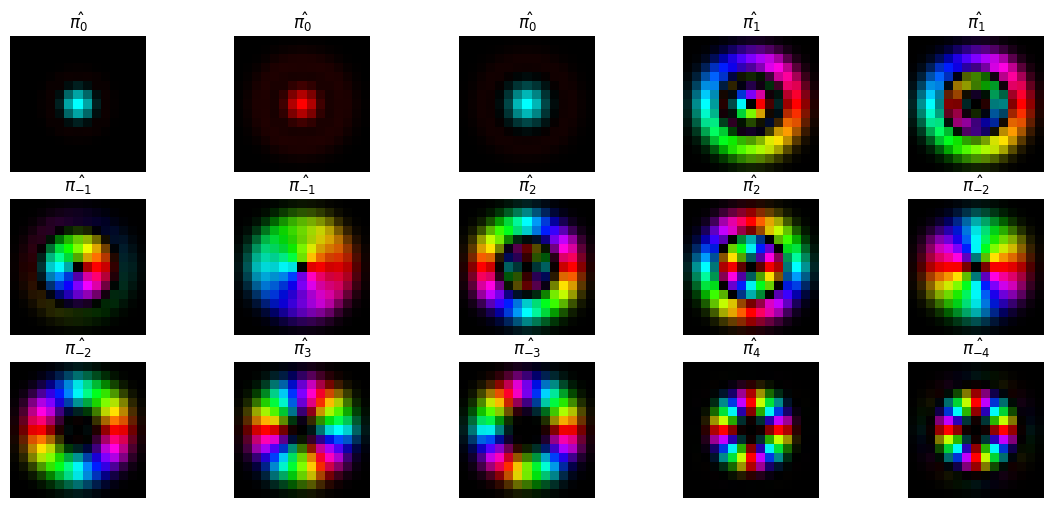

In [12]:
import matplotlib.pyplot as plt
# Plot all the filters
fig, axes = plt.subplots(3, 5, figsize=(14, 6)) 
for i, ax in enumerate(axes.flat):
    if i < filters.shape[0]:
        filter = filters[i][0][0].detach()
        ax.imshow(complex_to_rgb((filter).numpy()))
        ax.set_title(f'$\hat{{\pi_{{{orders[i]}}}}}$')
    ax.axis('off')

In [13]:
# Testing images
import torch 
from torchvision import transforms
from hippy2d.utils import get_testing_img, get_default_complex
# Set default to double precision
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pretend complex img of type 0 
test_img = get_testing_img(rgb=False)
test_img = transforms.ToTensor()(test_img).to(dtype=torch.float64)
rotated_img = torch.rot90(test_img, 1, [1, 2])
# 
test_rgb_img = get_testing_img(rgb=True)
test_rgb_img = transforms.ToTensor()(test_rgb_img).to(dtype=torch.float64)
rotated_rgb_img = torch.rot90(test_rgb_img, 1, [1, 2])

test_c_img = torch.view_as_complex(rearrange(test_rgb_img[:2], pattern="c h w -> 1 1 h w c").contiguous())
rot_test_c_img = torch.view_as_complex(rearrange(rotated_rgb_img[:2], pattern="c h w ->1 1 h w c").contiguous())

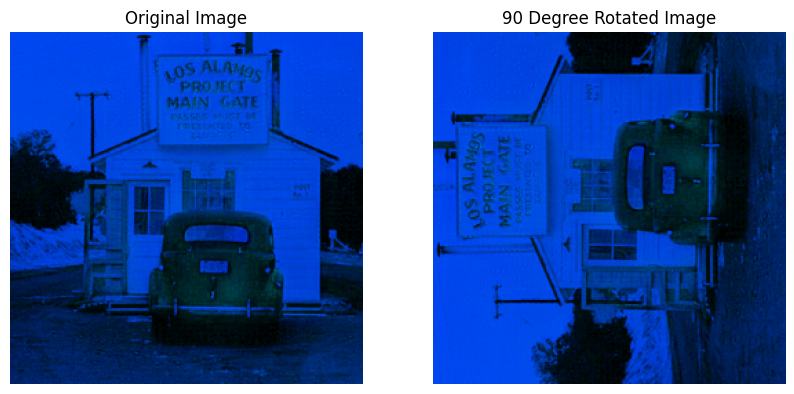

In [14]:
# Plot the images
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(complex_to_rgb(test_c_img[0][0].numpy()))
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(complex_to_rgb(rot_test_c_img[0][0].numpy()))
plt.title("90 Degree Rotated Image",)
plt.axis('off')
plt.show()



In [15]:
_filters = rearrange(filters, 'o oc ic h w -> (o oc) ic h w')
output = torch.conv2d(input=test_c_img,
                      weight=_filters)
#output = rearrange(output, 'b (m out) h w -> b m out h w')
output_rot = torch.conv2d(input=rot_test_c_img,
                          weight=_filters)
output = rearrange(output, 'b (m out) h w -> b m out h w', m=len(orders))[0]
output_rot = rearrange(output_rot, 'b (m out) h w -> b m out h w', m=len(orders))[0]


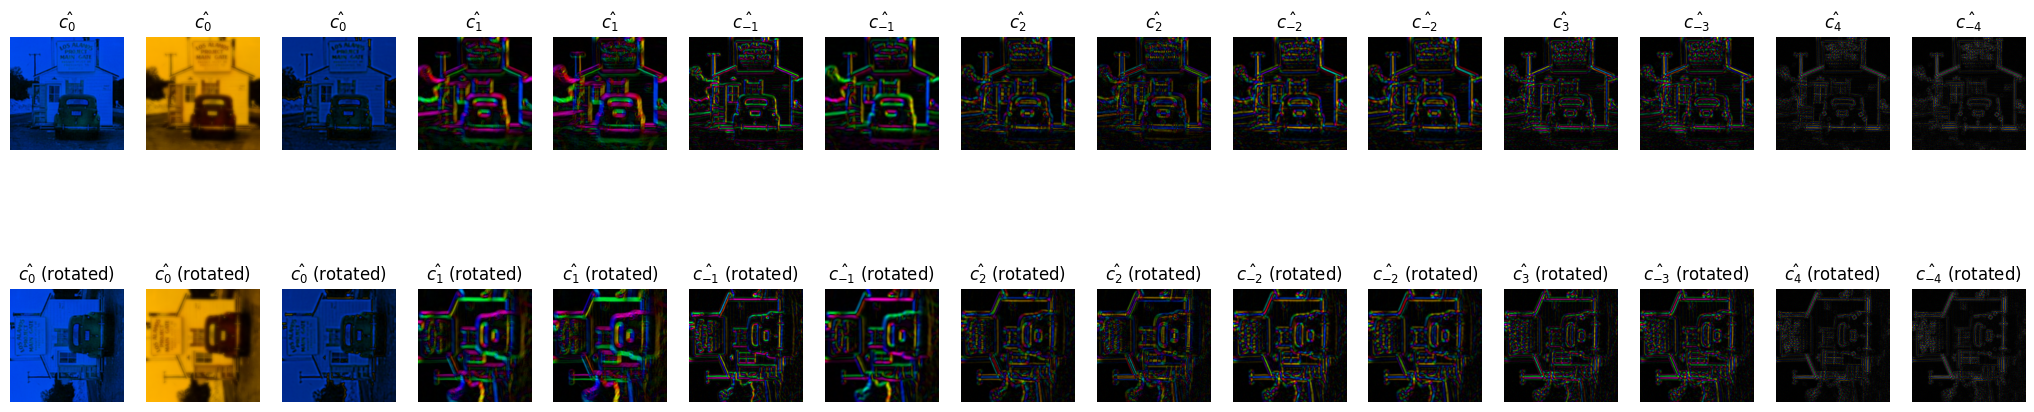

In [16]:
# plot the outputs in complex
OUTPUT_CHANNEL = 0
# plot all the channels
fig, axs = plt.subplots(2, output.shape[0], figsize=(26, 6))

for idx, ax in enumerate(axs[0].flat):
        ax.imshow(complex_to_rgb(output[idx][OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
        ax.axis('off')
        ax.set_title(f'$\hat{{c_{{{orders[idx]}}}}}$')
for idx, ax in enumerate(axs[1].flat):
        ax.imshow(complex_to_rgb(output_rot[idx][OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
        ax.axis('off')
        ax.set_title(f'$\hat{{c_{{{orders[idx]}}}}}$ (rotated)')

In [17]:
from hippy2d.flexibleconv2d import complex_power_moivre
def compute_types(output): 
    norm_factor = output[norm_factor_idx:norm_factor_idx + 1]
    type0 = torch.cat([output[~type0_mask], output[type0_mask] * (norm_factor  ** type0_exp)], dim=0)
    type1 = torch.cat([output[~type1_mask], output[type1_mask] * (norm_factor  ** type1_exp)], dim=0)

    type0_copy = output[type0_mask] * torch.view_as_complex(
        complex_power_moivre(torch.view_as_real(norm_factor),
                                        type0_exp,
                                        magnitude_func="copy")
    )

    type1_copy = output[type1_mask] * torch.view_as_complex(
        complex_power_moivre(torch.view_as_real(norm_factor),
                                        type1_exp,
                                        magnitude_func="copy")
    )
    type0_copy = torch.cat([output[~type0_mask], type0_copy, ], dim=0)
    type1_copy = torch.cat([output[~type1_mask], type1_copy], dim=0)
    return type0, type1, type0_copy, type1_copy

In [18]:
type0, type1, type0_copy, type1_copy = compute_types(output)
type0_rot, type1_rot, type0_copy_rot, type1_copy_rot = compute_types(output_rot)

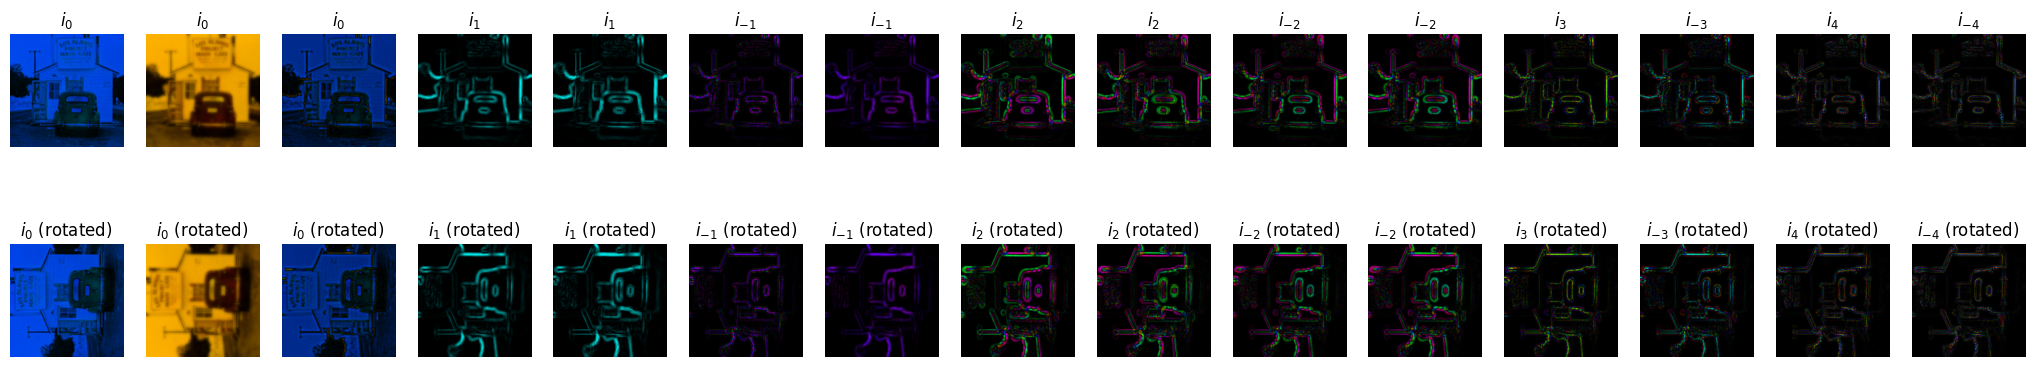

In [19]:
# Positive order invariants
fig, axs = plt.subplots(2, type0.shape[0], figsize=(26, 5))
for idx, ax in enumerate(axs[0].flat):
        ax.imshow(complex_to_rgb(type0_copy[idx][OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
        ax.axis('off')
        ax.set_title(f'$i_{{{orders[idx]}}}$') 
for idx, ax in enumerate(axs[1].flat):
        ax.imshow(complex_to_rgb(type0_copy_rot[idx][OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
        ax.axis('off')
        ax.set_title(f'$i_{{{orders[idx]}}}$ (rotated)')

# Assert the invariants are rotation invariant
assert torch.allclose(type0, torch.rot90(type0_rot, k=-1,dims=[-2, -1])), "Invariants are not rotation invariant"
# Asssert copies are also rotation invariant
assert torch.allclose(type0_copy, torch.rot90(type0_copy_rot, k=-1,dims=[-2, -1])), "Invariants with copy are not rotation invariant"

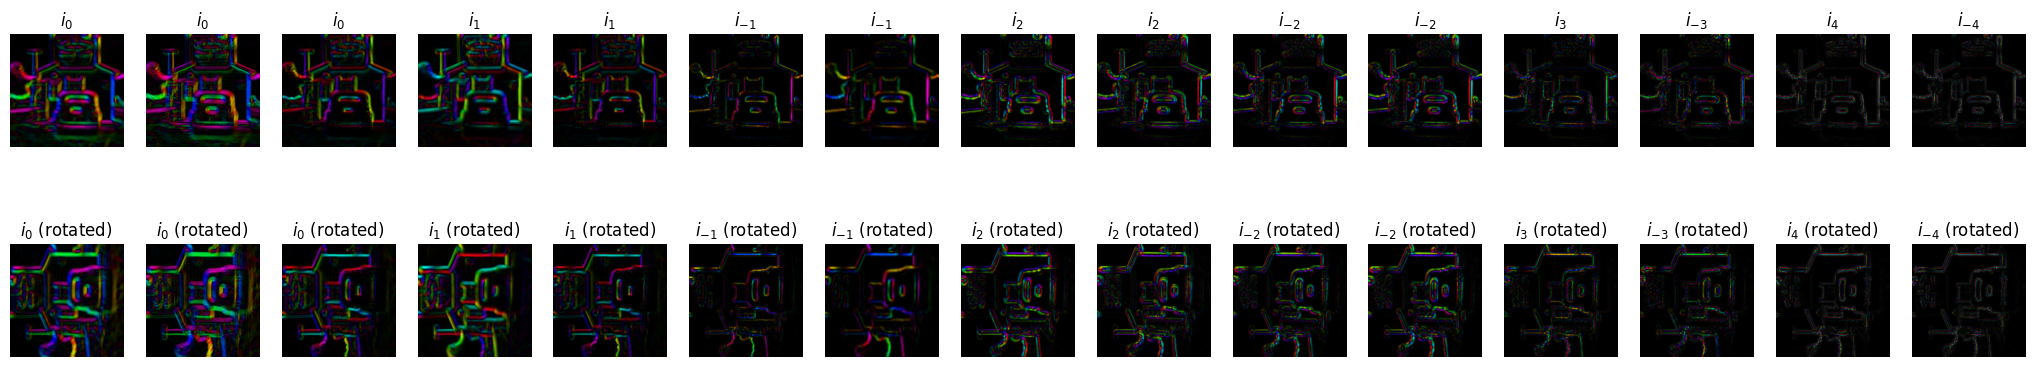

In [20]:
# plot type_1

fig, axs = plt.subplots(2, type1.shape[0], figsize=(26, 5))
for idx, ax in enumerate(axs[0].flat):
        ax.imshow(complex_to_rgb(type1_copy[idx][OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
        ax.axis('off')
        ax.set_title(f'$i_{{{orders[idx]}}}$') 
for idx, ax in enumerate(axs[1].flat):
        ax.imshow(complex_to_rgb(type1_copy_rot[idx][OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
        ax.axis('off')
        ax.set_title(f'$i_{{{orders[idx]}}}$ (rotated)')

# compensate by exp(i * theta) for type 1
compensate = torch.exp(torch.tensor(-1j * (torch.pi / 2)))
# Assert the invariants are rotation invariant
assert torch.allclose(type1*compensate, torch.rot90(type1_rot, k=-1,dims=[-2, -1])), "Invariants are not rotation invariant"
# Asssert copies are also rotation invariant
assert torch.allclose(type1_copy*compensate, torch.rot90(type1_copy_rot, k=-1,dims=[-2, -1])), "Invariants with copy are not rotation invariant"

In [32]:

from hippy2d.utils import get_default_complex
def init_radial_part(in_channels: int, out_channels: int, orders: List[int], ring_count: int):
    """
    Initializes the dict of weights

    Args:

        in_channels: input channels
        out_channels: output channels
        max_order: maximum rotation order from input and output
        ring_count (int): Number of rings for calculating the basis
    Returns:
        weights_dict: initialized dict of weights

    """
    weights = torch.zeros((len(orders), ring_count, in_channels, out_channels),
                            dtype=torch.get_default_dtype())
    for idx, _ in enumerate(orders):
        sh = [ring_count, in_channels, out_channels]
        # Initializes the weights using initialization method of He
        stddev = 0.4 * np.sqrt(2.0 / np.prod(sh[:3]))
        weights[idx] = torch.normal(torch.zeros(*sh), stddev)
    # Flat input & output channels
    return weights.view((len(orders), ring_count, in_channels * out_channels))

def get_angle_samples_count(kernel_size):
    return int(np.maximum(np.ceil(np.pi * kernel_size), 101))

def get_l2_neighbors(center, shape):
    lin = np.arange(shape) + 0.5
    jj, ii = np.meshgrid(lin, lin)
    ii = ii - center[1]
    jj = jj - center[0]
    return np.vstack((np.reshape(ii, -1), np.reshape(jj, -1)))

def get_interpolation_weights(fs, m, n_rings, angle_samples):
    """
    Used to construct the steerable filters using Radial basis functions.
    The filters are constructed on the patches of n_rings using Gaussian
    interpolation. (Code adapted from the tf code of Worrall et al., CVPR, 2017)

    Args:
        fs (int): filter size for the H-net convolutional layer
        m (int): max. rotation order for the steerable filters
        n_rings (int): No. of rings for the steerable filters
        angle_samples (int): No. of angle samples

    Returns:
        norm_weights (numpy): contains normalized weights for interpolation
        using the steerable filters
    """

    mid = int(np.floor(fs / 2))
    # Variance of Gaussian resampling
    std_gauss = (mid / n_rings) / 2
    # We define below radii up to n_rings-0.5 (as in Worrall et al, CVPR 2017)
    radii = np.linspace(m != 0, mid - 2 * std_gauss, n_rings)
    # We define pixel centers to be at positions 0.5
    center_pt = np.asarray([fs, fs]) / 2.

    # Extracting the set of angles to be sampled

    # Choosing the sampling locations for the rings
    lin = (2 * np.pi * np.arange(angle_samples)) / angle_samples
    ring_locations = np.vstack([-np.sin(lin), np.cos(lin)])

    # Create interpolation coefficient coordinates
    coords = get_l2_neighbors(center_pt, fs)

    # getting samples based on the chosen center_pt and the coords
    radii = radii[:, np.newaxis, np.newaxis, np.newaxis]
    ring_locations = ring_locations[np.newaxis, :, :, np.newaxis]
    diff = radii * ring_locations - coords[np.newaxis, :, np.newaxis, :]
    dist2 = np.sum(diff ** 2, axis=1)

    # Convert distances to weightings
    weights = np.exp(-0.5 * dist2 / (std_gauss ** 2))  # For bandwidth of 0.5

    # Normalizing the weights to calibrate the different steerable filters
    norm = np.sum(weights,
                    axis=2,
                    keepdims=True)
    assert np.all(norm != 0), "Normalizing by zero weights"
    return np.divide(weights,
                        norm,
                        where=(norm != 0)
                        )

def init_angular_part(kernel_size, orders, n_rings):
    N = get_angle_samples_count(kernel_size)
    weights2filter_sampler = []
    for order in orders:
        weights = get_interpolation_weights(kernel_size,
                                            m=order,
                                            n_rings=n_rings,
                                            angle_samples=N)
        low_pass_filter = np.dot(dft(N)[order, :], weights).T
        weights2filter_sampler.append(
                torch.from_numpy(low_pass_filter))
    return torch.stack(weights2filter_sampler)

import torch
import torch.nn as nn

class RealPointwiseOnComplex(nn.Module):
    """
    y = W x, where x is complex (C_in), W is real (C_out x C_in), applied per pixel.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.mix = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)

    def forward(self, x: torch.Tensor):  # x: [N, C_in, H, W], complex
        xr, xi = x.real, x.imag
        yr = self.mix(xr)               # same real W on both parts
        yi = self.mix(xi)
        return torch.complex(yr, yi)


class ComplexLearnableFlusser(torch.nn.Module):
    """ 
    Learnable Flusser layer as described in the notebook.
    """
    def __init__(self,
                 in_channels: int,
                 out_channels: int, 
                 orders: list = [-4, -3, -2, -2, -1, -1, 0, 0, 0, 1, 1, 2, 2, 3, 4],
                 ring_count: int=3,
                 kernel_size: int=15,
                 norm_factor_function="copy"): # copy when rotating only the phase
        super(ComplexLearnableFlusser, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.ring_count = ring_count
        self.kernel_size = kernel_size
        self.norm_factor_function = norm_factor_function

        assert 0 in orders, "No symmetric orders found"
        assert 1 in orders, "No order 1 found for normalization"
        def _sort(order): 
            return abs(order) + 0.5 if order < 0 else order 
        orders = np.array(sorted(orders, key=_sort))
        norm_factor_idx = np.argwhere(np.array(orders) == 1)[0,0]

        type0_mask = orders != 0
        type1_mask = orders != 1

        type0_exp = -orders[type0_mask]
        type1_exp = 1 - orders[type1_mask]
        type0_exp = torch.from_numpy(type0_exp[:,None, None, None])
        type1_exp = torch.from_numpy(type1_exp[:,None, None, None])

        self.register_buffer("orders", torch.tensor(orders, dtype=torch.int32))
        self.register_buffer("type0_mask", torch.tensor(type0_mask))
        self.register_buffer("type1_mask", torch.tensor(type1_mask))
        self.register_buffer("type0_exp", type0_exp)
        self.register_buffer("type1_exp", type1_exp)
        self.norm_factor_idx = norm_factor_idx

        # Init angular part that is fixed self.angular_part 
        # Note: This part can be also made learnable
        self.register_buffer("angular_part", init_angular_part(kernel_size, self.orders.tolist(), ring_count))
        # Init learnable radial part 
        self.weights = torch.nn.Parameter(init_radial_part(in_channels, out_channels, self.orders.tolist(), ring_count),
                                          requires_grad=True)
        # 1x1 real projection
        self.conv1x1_type0 = torch.nn.Conv2d(in_channels=len(orders) * out_channels,
                                             out_channels=out_channels,
                                             kernel_size=1,
                                             dtype=get_default_complex())
        self.conv1x1_type1 = RealPointwiseOnComplex(in_channels=len(orders) * out_channels,
                                                   out_channels=out_channels)

    def forward(self, x):
        assert x.dtype == get_default_complex(), "Input tensor must be of complex dtype"
        # Calculate the weights
        filters = rearrange(
            tensor=torch.matmul(self.angular_part, self.weights.to(get_default_complex())),
            pattern="o (h w) (ic oc) -> (o oc) ic h w",
            h=self.kernel_size,
            w=self.kernel_size,
            ic=self.in_channels,
            oc=self.out_channels)
        # Perform convolution 
        x = torch.conv2d(input=x,
                         weight=filters)
        x = rearrange(x, 'b (m out) h w -> b m out h w', m=len(self.orders))
        norm_factor = torch.view_as_real(x[:, self.norm_factor_idx:self.norm_factor_idx + 1]) 
        # Compute type 0 copy 
        type0 = torch.cat(dim=1, 
                          tensors=[x[:, ~self.type0_mask],
                                   x[:, self.type0_mask] * torch.view_as_complex(
                                       complex_power_moivre(norm_factor,
                                                           self.type0_exp,
                                                           magnitude_func=self.norm_factor_function)
                                   )
                          ])
        type1 = torch.cat(dim=1, 
                          tensors=[x[:, ~self.type1_mask],
                                   x[:, self.type1_mask] * torch.view_as_complex(
                                       complex_power_moivre(norm_factor,
                                                           self.type1_exp,
                                                           magnitude_func=self.norm_factor_function)
                                   )
                          ])
        type0 = self.conv1x1_type0(rearrange(type0, 'b m out h w -> b (m out) h w'))
        # TODO: This can be only a 
        type1 = self.conv1x1_type1(rearrange(type1, 'b m out h w -> b (m out) h w'))
        return type0, type1 



In [33]:
# Test invariance of the Learnable Flusser layer
invariant_layer = ComplexLearnableFlusser(in_channels=1, out_channels=2, ring_count=3, kernel_size=15)
# freeze
with torch.no_grad():
    for param in invariant_layer.parameters():
        param.requires_grad = False

type0, type1 = invariant_layer(test_c_img)
rot_type0, rot_type1 = invariant_layer(rot_test_c_img)

assert torch.allclose(type0, torch.rot90(rot_type0, k=-1,dims=[-2, -1])), "Invariants are not rotation invariant"
compensate = torch.exp(torch.tensor(-1j * (torch.pi / 2)))
# TODO: This cannot arbitary complex number 
assert torch.allclose(type1*compensate, torch.rot90(rot_type1, k=-1,dims=[-2, -1])), "Invariants are not rotation invariant"

#

In [ ]:
rota

In [ ]:
type_exp = torch.tensor(orders[norm_factor_idx+1: ]) - 1 
